<p align="center">
  <img src="assets/logo.png" alt="Logo Indicium" width="220"/>
</p>

# Desafio Indicium - Dados & AI
Notebook final com visão analítica estruturada dos dados de vendas, clientes e produtos, incluindo KPIs, sazonalidade, ranking de produtos/clientes, baseline de previsão e recomendação item-item.

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use('seaborn-v0_8')


def format_brl(valor):
    if pd.isna(valor):
        return '-'
    texto = f'{valor:,.2f}'
    texto = texto.replace(',', 'X').replace('.', ',').replace('X', '.')
    return f'R$ {texto}'

## 1) Carga e preparação dos dados

In [18]:
vendas_path = 'datasets/vendas_2023_2024.csv'
if not os.path.exists(vendas_path):
    vendas_path = 'datasets_transformers/vendas_normalizado.csv'

vendas = pd.read_csv(vendas_path)
produtos = pd.read_csv('datasets_transformers/produtos_clean_import.csv')
clientes = pd.read_json('datasets/clientes_crm.json')

vendas['sale_date'] = pd.to_datetime(vendas['sale_date'], errors='coerce', format='mixed', dayfirst=True)
vendas = vendas.dropna(subset=['sale_date']).copy()

vendas['id_product'] = vendas['id_product'].astype(str)
vendas['id_client'] = vendas['id_client'].astype(str)
produtos['code'] = produtos['code'].astype(str)
clientes['code'] = clientes['code'].astype(str)

base = vendas.merge(produtos[['code', 'name', 'actual_category']], left_on='id_product', right_on='code', how='left')
base = base.merge(clientes[['code', 'full_name', 'location']], left_on='id_client', right_on='code', how='left', suffixes=('', '_cliente'))

print('Arquivo de vendas usado:', vendas_path)
print('Período:', base['sale_date'].min().date(), 'a', base['sale_date'].max().date())
print('Registros:', len(base))

Arquivo de vendas usado: datasets/vendas_2023_2024.csv
Período: 2023-01-01 a 2024-12-31
Registros: 10364


## 2) KPIs executivos

In [19]:
kpi_faturamento = base['total'].sum()
kpi_qtd = base['qtd'].sum()
kpi_clientes = base['id_client'].nunique()
kpi_produtos = base['id_product'].nunique()
ticket_medio = base['total'].mean()

kpi_df = pd.DataFrame({
    'KPI': ['Faturamento Total', 'Qtd Total Vendida', 'Clientes Únicos', 'Produtos Vendidos', 'Ticket Médio por Venda'],
    'Valor': [kpi_faturamento, kpi_qtd, kpi_clientes, kpi_produtos, ticket_medio]
})

kpi_df_exibicao = kpi_df.copy()
kpi_df_exibicao['Valor'] = kpi_df_exibicao['Valor'].astype(object)
kpi_df_exibicao.loc[kpi_df_exibicao['KPI'].isin(['Faturamento Total', 'Ticket Médio por Venda']), 'Valor'] = (
    kpi_df_exibicao.loc[kpi_df_exibicao['KPI'].isin(['Faturamento Total', 'Ticket Médio por Venda']), 'Valor'].apply(format_brl)
)
kpi_df_exibicao.loc[~kpi_df_exibicao['KPI'].isin(['Faturamento Total', 'Ticket Médio por Venda']), 'Valor'] = (
    kpi_df_exibicao.loc[~kpi_df_exibicao['KPI'].isin(['Faturamento Total', 'Ticket Médio por Venda']), 'Valor'].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
)

kpi_df_exibicao

,KPI,Valor
0,Faturamento Total,"R$ 2.752.951.440,30"
1,Qtd Total Vendida,82.937
2,Clientes Únicos,49
3,Produtos Vendidos,150
4,Ticket Médio por Venda,"R$ 265.626,35"


## 3) Tendência temporal

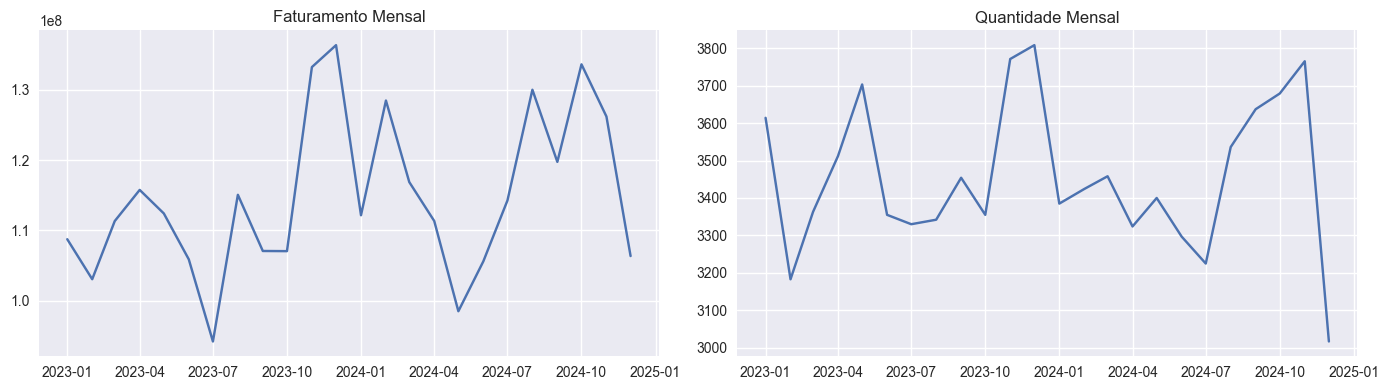

In [20]:
mensal = base.set_index('sale_date').resample('MS').agg({'total':'sum', 'qtd':'sum'}).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(mensal['sale_date'], mensal['total'])
ax[0].set_title('Faturamento Mensal')
ax[1].plot(mensal['sale_date'], mensal['qtd'])
ax[1].set_title('Quantidade Mensal')
plt.tight_layout()
plt.show()

## 4) Top produtos e categorias

In [21]:
top_produtos = (
    base.groupby(['id_product','name'], as_index=False)
    .agg(faturamento=('total','sum'), quantidade=('qtd','sum'))
    .sort_values('faturamento', ascending=False)
    .head(10)
)

top_categorias = (
    base.groupby('actual_category', as_index=False)
    .agg(faturamento=('total','sum'), quantidade=('qtd','sum'))
    .sort_values('faturamento', ascending=False)
)

top_produtos_exibicao = top_produtos.copy()
top_produtos_exibicao['faturamento'] = top_produtos_exibicao['faturamento'].apply(format_brl)
top_produtos_exibicao['quantidade'] = top_produtos_exibicao['quantidade'].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
top_produtos_exibicao = top_produtos_exibicao.rename(columns={
    'id_product': 'id_produto',
    'name': 'produto'
})
top_produtos_exibicao = top_produtos_exibicao.reset_index(drop=True)

top_categorias_exibicao = top_categorias.copy()
top_categorias_exibicao['faturamento'] = top_categorias_exibicao['faturamento'].apply(format_brl)
top_categorias_exibicao['quantidade'] = top_categorias_exibicao['quantidade'].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
top_categorias_exibicao = top_categorias_exibicao.rename(columns={
    'actual_category': 'categoria'
})
top_categorias_exibicao = top_categorias_exibicao.head(3).reset_index(drop=True)
top_categorias_exibicao.insert(0, 'ranking', top_categorias_exibicao.index + 1)

display(top_produtos_exibicao.style.hide(axis='index'))
display(top_categorias_exibicao.style.hide(axis='index'))

id_produto,produto,faturamento,quantidade
62,Motor Diesel Yanmar Velocity 37HP,"R$ 178.500.056,40",1.792
76,Motor Diesel Honda Aero 205HP,"R$ 83.539.339,40",578
71,Motor Elétrico Torqeedo Pulse 300HP,"R$ 81.567.066,65",641
73,Motor de Popa Torqeedo Core Hydra Flux 162HP,"R$ 69.554.254,80",497
63,Motor Elétrico Torqeedo Ion Orca Vox 186HP,"R$ 68.817.185,90",505
80,Motor de Popa Volvo Maré 69HP,"R$ 67.332.086,05",533
91,Motor Elétrico Tohatsu Zenith Oceanic 113HP,"R$ 66.829.268,70",506
54,Motor de Popa Yamaha Evo Dash 155HP,"R$ 65.859.716,10",556
81,Motor Elétrico Torqeedo Barracuda Magnum Helix 101HP,"R$ 64.195.127,60",538
72,Motor de Popa Volvo Hydro Dash 256HP,"R$ 63.057.815,65",647


ranking,categoria,faturamento,quantidade
1,Propulsão,"R$ 2.210.149.183,15",27.036
2,Eletrônicos,"R$ 467.194.126,80",27.099
3,Ancoragem,"R$ 75.608.130,35",28.802


## 5) Clientes (recorrência e valor)

In [22]:
clientes_rank = (
    base.groupby(['id_client','full_name'], as_index=False)
    .agg(
        faturamento=('total','sum'),
        pedidos=('id','count'),
        qtd=('qtd','sum')
    )
    .sort_values(['faturamento','pedidos'], ascending=False)
)

clientes_rank_exibicao = clientes_rank.head(10).copy()
clientes_rank_exibicao['faturamento'] = clientes_rank_exibicao['faturamento'].apply(format_brl)
clientes_rank_exibicao['pedidos'] = clientes_rank_exibicao['pedidos'].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
clientes_rank_exibicao['qtd'] = clientes_rank_exibicao['qtd'].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
clientes_rank_exibicao = clientes_rank_exibicao.rename(columns={
    'id_client': 'id_cliente',
    'full_name': 'cliente',
    'qtd': 'quantidade'
})

display(clientes_rank_exibicao.style.hide(axis='index'))

id_cliente,cliente,faturamento,pedidos,quantidade
42,Márcia Figueiredo,"R$ 74.021.826,35",232,1.891
9,Lucas Guedes Cunha Lopes,"R$ 72.697.344,85",234,1.794
36,Francisca Ribeiro Pinheiro,"R$ 69.349.933,20",230,1.847
2,Fernanda Azevedo Soares Nunes Vieira,"R$ 67.717.055,25",225,2.051
47,Gabriela Barros Lacerda,"R$ 67.668.333,05",202,1.621
26,Luiz Borges Gomes Araújo,"R$ 66.653.100,20",224,1.899
48,Letícia Torres Peixoto Oliveira,"R$ 66.606.944,95",233,1.947
28,Bianca Rodrigues,"R$ 65.619.098,85",220,1.789
25,Femininos Antunes Lopes Ribeiro Amaral,"R$ 65.560.908,15",228,2.028
15,Carla Lopes Alves Pacheco Rocha,"R$ 64.917.152,55",245,2.026


## 6) Resumo de previsão (produto Yamaha)
Baseline: média móvel 7 dias e baseline aprimorado por dia da semana + fallback 7d.

In [23]:
produto_alvo = 'Motor de Popa Yamaha Evo Dash 155HP'
codigo_alvo = produtos.loc[produtos['name'].str.strip().str.lower()==produto_alvo.lower(),'code'].iloc[0]

df_prod = base[base['id_product'] == codigo_alvo].copy()
serie = (
    df_prod.groupby(df_prod['sale_date'].dt.date)['qtd'].sum()
    .rename('vendas')
    .to_frame()
)
serie.index = pd.to_datetime(serie.index)
serie = serie.asfreq('D', fill_value=0)['vendas']

train_end = pd.Timestamp('2023-12-31')
test_start = pd.Timestamp('2024-01-01')
test_end = pd.Timestamp('2024-01-31')

real = serie[test_start:test_end]
pred_7d = serie.rolling(7, min_periods=1).mean().shift(1)[test_start:test_end].fillna(0)

serie_train = serie[:train_end]
weekday_mean = serie_train.groupby(serie_train.index.dayofweek).mean()
pred_semana = pd.Series([weekday_mean.get(d, np.nan) for d in real.index.dayofweek], index=real.index)
pred_melhor = pred_semana.fillna(pred_7d).fillna(0)

mae_7d = mean_absolute_error(real, pred_7d)
mae_melhor = mean_absolute_error(real, pred_melhor)

pd.DataFrame({'modelo':['Média móvel 7d','Dia da semana + fallback'], 'MAE':[mae_7d, mae_melhor]})

,modelo,MAE
0,Média móvel 7d,0.995392
1,Dia da semana + fallback,1.145920


## 7) Recomendação item-item

In [24]:
interacoes = base[['id_client','id_product']].drop_duplicates().copy()
interacoes['valor'] = 1
matriz_ui = interacoes.pivot_table(index='id_client', columns='id_product', values='valor', aggfunc='max', fill_value=0).astype(np.int8)
matriz_iu = matriz_ui.T
sim = cosine_similarity(matriz_iu.values)
sim_df = pd.DataFrame(sim, index=matriz_iu.index, columns=matriz_iu.index)

produto_ref_nome = 'GPS Garmin Vortex Maré Drift'
produto_ref_code = produtos.loc[produtos['name'].str.strip().str.lower()==produto_ref_nome.lower(),'code'].iloc[0]

ranking = (
    sim_df.loc[produto_ref_code]
    .drop(labels=[produto_ref_code], errors='ignore')
    .sort_values(ascending=False)
    .head(5)
    .rename('similaridade')
    .reset_index()
)
ranking = ranking.rename(columns={ranking.columns[0]:'id_product'})
ranking = ranking.merge(produtos[['code','name']], left_on='id_product', right_on='code', how='left')

ranking_exibicao = ranking[['id_product', 'name', 'similaridade']].rename(columns={
    'id_product': 'id_produto',
    'name': 'produto'
})

display(ranking_exibicao.style.hide(axis='index'))

id_produto,produto,similaridade
94,Motor de Popa Volvo Magnum 276HP,0.869626
11,GPS Furuno Swift Leviathan Poseidon,0.868037
35,Radar Furuno Swift,0.853913
115,Cabo de Nylon Delta Force Magnum Leviathan,0.850000
1,Transponder AIS Maré Magnum,0.850000


## 8) Distribuição de prejuízos por produto

In [28]:
import plotly.express as px

custos_norm = pd.read_csv('datasets_transformers/custos_importacao_normalizado.csv')
cambio_df   = pd.read_csv('datasets_transformers/cambio.csv')

custos_norm['start_date'] = pd.to_datetime(custos_norm['start_date'])
cambio_df['date']         = pd.to_datetime(cambio_df['date'])
cambio_df = cambio_df.sort_values('date')

vendas_m = vendas.copy()
vendas_m['_pid'] = pd.to_numeric(vendas_m['id_product'], errors='coerce')

partes = []
for pid, grp in vendas_m.groupby('_pid'):
    c = custos_norm[custos_norm['product_id'] == pid].sort_values('start_date')
    if c.empty:
        grp = grp.copy(); grp['usd_price'] = np.nan
    else:
        grp = pd.merge_asof(grp.sort_values('sale_date'),
                            c[['start_date', 'usd_price']],
                            left_on='sale_date', right_on='start_date',
                            direction='backward')
    partes.append(grp)

vendas_custo = pd.concat(partes, ignore_index=True).drop(columns=['_pid'])
vendas_custo = pd.merge_asof(vendas_custo.sort_values('sale_date'),
                             cambio_df[['date', 'taxa_venda']],
                             left_on='sale_date', right_on='date',
                             direction='backward')

vendas_custo['custo_brl'] = (vendas_custo['qtd']
                              * vendas_custo['usd_price'].fillna(0)
                              * vendas_custo['taxa_venda'].fillna(5.0))
vendas_custo['margem'] = vendas_custo['total'] - vendas_custo['custo_brl']

margem_prod = (
    vendas_custo
    .merge(produtos[['code', 'name']], left_on='id_product', right_on='code', how='left')
    .groupby(['id_product', 'name'], as_index=False)['margem'].sum()
    .sort_values('margem')
)
prejuizos = margem_prod[margem_prod['margem'] < 0]

fig_q4 = px.bar(
    prejuizos,
    x='margem', y='name', orientation='h',
    title='Ranking de produtos com margem acumulada negativa (prejuízo)',
    labels={'margem': 'Margem acumulada (R$)', 'name': 'Produto'},
    color='margem', color_continuous_scale='Reds_r',
    height=max(320, len(prejuizos) * 32 + 80),
)
fig_q4.update_layout(coloraxis_showscale=False, xaxis_tickformat=',.0f')
fig_q4.show()

## 9) Clientes com maior lucro acumulado

In [29]:
lucro_cli = (
    vendas_custo
    .merge(clientes[['code', 'full_name']], left_on='id_client', right_on='code', how='left')
    .groupby(['id_client', 'full_name'], as_index=False)['margem'].sum()
    .sort_values('margem', ascending=False)
    .head(10)
)

fig_q5 = px.bar(
    lucro_cli.sort_values('margem'),
    x='margem', y='full_name', orientation='h',
    title='Top 10 clientes por lucro acumulado',
    labels={'margem': 'Lucro acumulado (R$)', 'full_name': 'Cliente'},
    color='margem', color_continuous_scale='Greens',
    height=420,
)
fig_q5.update_layout(coloraxis_showscale=False, xaxis_tickformat=',.0f')
fig_q5.show()

## 10) Vendas médias por dia da semana (com dias sem venda)

In [27]:
_dias_pt = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta',
            4: 'Sexta',   5: 'Sábado', 6: 'Domingo'}

_dr      = pd.date_range(vendas['sale_date'].min(), vendas['sale_date'].max(), freq='D')
_all     = pd.DataFrame({'sale_date': _dr})

_daily   = vendas[['sale_date', 'total']].copy()
_daily['_d'] = _daily['sale_date'].dt.normalize()
_dt      = _daily.groupby('_d', as_index=False)['total'].sum().rename(columns={'_d': 'sale_date'})

_full    = _all.merge(_dt, on='sale_date', how='left').fillna(0)
_full['dow'] = _full['sale_date'].dt.dayofweek
_full['dia'] = _full['dow'].map(_dias_pt)

_media   = _full.groupby(['dow', 'dia'], as_index=False)['total'].mean().sort_values('dow')

fig_q6 = px.bar(
    _media, x='dia', y='total',
    title='Faturamento médio por dia da semana (dias sem venda = R$ 0)',
    labels={'total': 'Faturamento médio (R$)', 'dia': 'Dia da semana'},
    category_orders={'dia': list(_dias_pt.values())},
)
fig_q6.update_layout(yaxis_tickformat=',.0f')
fig_q6.show()

## Conclusões
- O dataset permite análises operacionais e de recomendação sem infraestrutura de Big Data.
- O baseline de previsão pode ser melhorado com modelos de demanda intermitente (Croston/TSB) e variáveis externas.
- O recomendador item-item atende bem ao caso de vitrine, mas sofre com esparsidade/cold start.